In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_jsonl(filepath):
    data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():
                data.append(json.loads(line))

    return data

In [3]:
run_name = "ch09_train"

checkpoint_dir = Path("data") / "ch09"

In [4]:
#epoches, steps = [], []
#train_losses, val_losses = [], []
#learning_rates, created_at = [], []

records = []

json_files = sorted(
    checkpoint_dir.glob("checkpoint_*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    #tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    #epoch, step = int(tags[0]), int(tags[1])
    records.append((
        data['epoch'], data['step'], data['train_loss'], data['val_loss'],
        data['learning_rate'], data['created_at']),
    )

In [5]:
#df = pd.DataFrame({
#    "epoch": epoches,
#    "step": steps,
#    "train_loss": train_losses,
#    "val_loss": val_losses,
#    "learning_rate": learning_rates,
#    "created_at": created_at,
#})

columns=["epoch", "step", "train_loss", "val_loss", "learning_rate", "created_at"]
df = pd.DataFrame.from_records(records, columns=columns)
df = df.sort_values(by='step', ascending=True)
steps = df['step'].apply(lambda x: x/1e3).to_list()
df['step'] = df['step'].apply(lambda x: f"{x:_}")

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

In [6]:
#print(df.nsmallest(1, 'train_loss'))
#pd.concat((df.head(10), df.tail(10)))

df.head(30)

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,8_000,4.483925,4.491979,0.000038,2025-09-15T14:54:44%:z
1,1,16_000,3.664065,3.767551,0.000076,2025-09-15T15:25:50%:z
2,1,24_000,3.132821,3.307736,0.000114,2025-09-15T15:56:52%:z
3,1,32_000,2.760071,2.984072,0.000152,2025-09-15T16:59:42%:z
4,1,40_000,2.548054,2.810270,0.000191,2025-09-15T17:44:57%:z
5,1,48_000,2.392028,2.710667,0.000229,2025-09-15T18:16:03%:z
6,1,56_000,2.291321,2.651382,0.000267,2025-09-15T18:47:07%:z
7,1,64_000,2.167756,2.592231,0.000300,2025-09-15T19:18:20%:z
8,1,72_000,2.089280,2.563814,0.000300,2025-09-15T19:49:36%:z
9,1,80_000,2.011697,2.533019,0.000299,2025-09-15T20:27:55%:z


In [7]:
df.tail(30)

,epoch,step,train_loss,val_loss,learning_rate,created_at
179,11,1_360_000,1.031241,2.643625,0.000010,2025-09-22T05:11:56%:z
180,11,1_368_000,1.028391,2.630845,0.000010,2025-09-22T05:43:27%:z
181,11,1_376_000,1.023406,2.651575,0.000010,2025-09-22T06:14:59%:z
182,11,1_384_000,1.021596,2.645196,0.000010,2025-09-22T06:46:31%:z
183,11,1_385_527,1.020838,2.638775,0.000010,2025-09-22T06:54:56%:z
184,12,1_392_000,1.020341,2.649894,0.000010,2025-09-22T07:20:55%:z
185,12,1_400_000,1.017714,2.651863,0.000010,2025-09-22T07:52:32%:z
186,12,1_408_000,1.016332,2.645827,0.000010,2025-09-22T08:24:10%:z
187,12,1_416_000,1.016247,2.640593,0.000010,2025-09-22T08:55:47%:z
188,12,1_424_000,1.013831,2.634169,0.000010,2025-09-22T09:27:23%:z


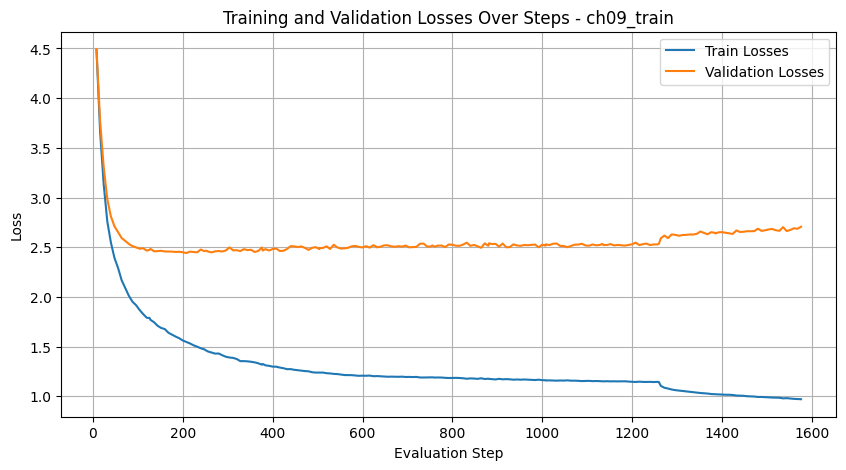

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['train_loss'], label="Train Losses")
plt.plot(steps, df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

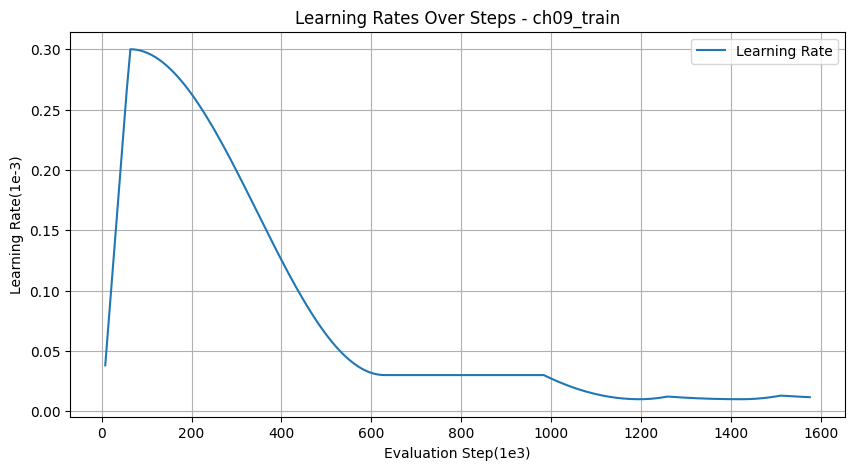

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")